In [1]:
import os 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [ ]:
def read_txt(file_path):
    with open(file_path, 'r') as file:
        content = file.readlines()
    return content
oplsaa = read_txt(  "./oplsaa.lt")
oplsaa2008 = read_txt(  "./oplsaa2008.lt")
oplsaa2024 = read_txt(  "./oplsaa2024.lt")
oplsaa
def find_atoms(oplsaa_lines,STR):
    # STR =    'write_once(\"In Charges\")'
    for i,line in enumerate(oplsaa_lines):
        if STR in line:
            start = i + 1
            break
    oplsaa_lines = oplsaa_lines[start :]
    for i,line in enumerate(oplsaa_lines):
        if "}" in line:
            end = i
            break
    ls = []
    oplsaa_lines = oplsaa_lines[:end]
    for i in range(len(oplsaa_lines)):

        A =  oplsaa_lines[i].strip()
        if "@atom:" in A :
            ls.append(A)
        
    return ls
def split_atom_info(atom_info_lines, atom_info_lines_DATAMASS, INFO_PREFIX ):
    EXCEPT_KEYWORD = ["DON'T USE(OPLSUA)"]
    INFO_LIST = []
    INFO_LIST2 = []
    for line in atom_info_lines:
        A = line.split("@atom:")
        B = A[1]
        C = B.split(" charge ")
        ATOM_INDEX  = C[0].strip()
        D = C[1]
        E = D.split("#")
        CHARGE = E[0].strip()
        INFO  = E[1].strip()
        if any(keyword in INFO for keyword in EXCEPT_KEYWORD):
            continue

        INFO_LIST.append((ATOM_INDEX, CHARGE, INFO))
    for line in atom_info_lines_DATAMASS:
        A = line.split("@atom:")
        B = A[1]
        C = B.split( )
        ATOM_INDEX  = C[0].strip()
        DATAMASS = C[1].strip()
        INFO_LIST2.append((ATOM_INDEX, DATAMASS))
    # Merge INFO_LIST and INFO_LIST2 based on ATOM_INDEX
    merged_info = []
    for atom_info in INFO_LIST:
        atom_index = atom_info[0]
        charge = atom_info[1]
        info = atom_info[2]
        datamass = next((item[1] for item in INFO_LIST2 if item[0] == atom_index), None)
        merged_info.append((atom_index, charge, info, datamass, INFO_PREFIX))
    return merged_info
DATAMASSSTR = "write_once(\"Data Masses\")"
CHARGESTR = "write_once(\"In Charges\")"
atom_info_lines_oplsaa = find_atoms(oplsaa,CHARGESTR)
atom_info_lines_oplsaa_DATAMASS = find_atoms(oplsaa,DATAMASSSTR)
atom_info_oplsaa = split_atom_info(atom_info_lines_oplsaa,atom_info_lines_oplsaa_DATAMASS, "oplsaa.lt")

atom_info_lines_oplsaa2008 = find_atoms(oplsaa2008,CHARGESTR)
atom_info_lines_oplsaa2008_DATAMASS = find_atoms(oplsaa2008,DATAMASSSTR)
atom_info_oplsaa2008 = split_atom_info(atom_info_lines_oplsaa2008,atom_info_lines_oplsaa2008_DATAMASS, "oplsaa2008.lt")

atom_info_lines_oplsaa2024 = find_atoms(oplsaa2024,CHARGESTR)
atom_info_lines_oplsaa2024_DATAMASS = find_atoms(oplsaa2024,DATAMASSSTR)
atom_info_oplsaa2024 = split_atom_info(atom_info_lines_oplsaa2024,atom_info_lines_oplsaa2024_DATAMASS, "oplsaa2024.lt")
atom_info_oplsaa2024

ALL_LIST  = atom_info_oplsaa + atom_info_oplsaa2008 + atom_info_oplsaa2024
df_all = pd.DataFrame(ALL_LIST, columns=["Atom_Index", "Charge", "Info", "DataMass", "Source"])
df_all.to_csv("oplsaa_combined_atom_info.csv", index=False)


('436', '2.500', 'U  - U~   | U in UO2+ J Mol Struct 366, 55 (96)', '238.029')
('697', '3.000', 'Ac - Ac   | Ac+3 Actinide params -', '227.000')
('698', '4.000', 'Th - Th   | Th+4', '232.038')
('699', '3.000', 'Am - Am   | Am+3 F. van Veggel', '243.000')


(array([211., 656.,  20.,  49.,  20.,   0.,   0.,   0.,   1.,   8.,   5.,
          0.,   0.,   0.,   0.,   6.,   5.,   2.,   1.,   1.,   0.,   1.,
          0.,   0.,   0.,   0.,   0.,   0.,   2.,   2.]),
 array([1.000e-17, 8.100e+00, 1.620e+01, 2.430e+01, 3.240e+01, 4.050e+01,
        4.860e+01, 5.670e+01, 6.480e+01, 7.290e+01, 8.100e+01, 8.910e+01,
        9.720e+01, 1.053e+02, 1.134e+02, 1.215e+02, 1.296e+02, 1.377e+02,
        1.458e+02, 1.539e+02, 1.620e+02, 1.701e+02, 1.782e+02, 1.863e+02,
        1.944e+02, 2.025e+02, 2.106e+02, 2.187e+02, 2.268e+02, 2.349e+02,
        2.430e+02]),
 <BarContainer object of 30 artists>)

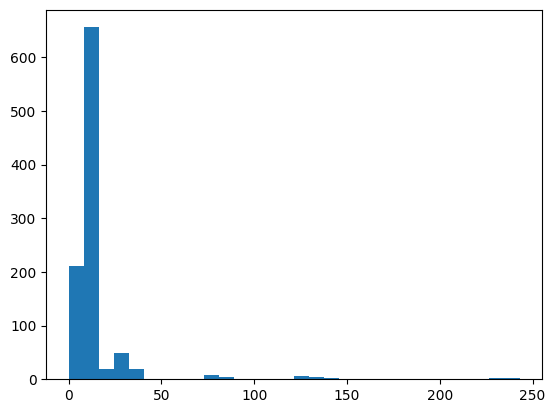

In [41]:
masses = []
for i in atom_info_oplsaa:
    mass = i[3]
    masses.append(mass)
    if float(mass) > 200:
        print(i)
plt.hist([float(i) for i in masses], bins=30)

In [55]:
import pandas as pd
import periodictable as pt
import os

# ----- 설정 -----
INPUT_CSV = "oplsaa_combined_atom_info.csv"  # 입력 파일
OUTPUT_DIR = "grouped_by_element"            # 출력 폴더
MASS_TOL = 0.2  # 허용 오차 (amu)

# ----- 원소 정보 테이블 생성 (원자번호 포함) -----
atomic_table = {
    el.symbol: {"Z": el.number, "mass": el.mass}
    for el in pt.elements if el.symbol
}

# ----- 원자 질량으로 Element 추정 함수 -----
def guess_element_from_mass(mass, tol=MASS_TOL):
    for symbol, info in atomic_table.items():
        if abs(info["mass"] - mass) <= tol:
            return symbol, info["Z"]
    return "Unknown", 0  # 원소를 못 맞추면 Unknown 처리

# ----- 실행 -----
def split_atoms_by_mass(input_csv, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    df = pd.read_csv(input_csv)

    if "DataMass" not in df.columns:
        raise ValueError("CSV에 'DataMass' 열이 필요합니다.")

    # 원자 질량 기반 원소 추정
    df[["ElementGuess", "AtomicNumber"]] = df["DataMass"].apply(
        lambda m: pd.Series(guess_element_from_mass(m))
    )

    # 원소 별로 그룹핑해서 CSV 출력
    for (element, z), group in df.groupby(["ElementGuess", "AtomicNumber"]):
        filename = f"{z}_{element}.csv"
        filepath = os.path.join(output_dir, filename)
        group.to_csv(filepath, index=False)
        print(f"[+] Saved {len(group)} rows → {filepath}")

    print("\n✅ 작업 완료!")

# ----- 실행 -----
split_atoms_by_mass(INPUT_CSV, OUTPUT_DIR)


[+] Saved 3 rows → grouped_by_element\89_Ac.csv
[+] Saved 2 rows → grouped_by_element\13_Al.csv
[+] Saved 3 rows → grouped_by_element\95_Am.csv
[+] Saved 11 rows → grouped_by_element\18_Ar.csv
[+] Saved 2 rows → grouped_by_element\5_B.csv
[+] Saved 6 rows → grouped_by_element\56_Ba.csv
[+] Saved 2 rows → grouped_by_element\4_Be.csv
[+] Saved 22 rows → grouped_by_element\35_Br.csv
[+] Saved 1400 rows → grouped_by_element\6_C.csv
[+] Saved 37 rows → grouped_by_element\17_Cl.csv
[+] Saved 6 rows → grouped_by_element\55_Cs.csv
[+] Saved 3 rows → grouped_by_element\63_Eu.csv
[+] Saved 40 rows → grouped_by_element\9_F.csv
[+] Saved 3 rows → grouped_by_element\64_Gd.csv
[+] Saved 586 rows → grouped_by_element\1_H.csv
[+] Saved 7 rows → grouped_by_element\2_He.csv
[+] Saved 16 rows → grouped_by_element\53_I.csv
[+] Saved 6 rows → grouped_by_element\19_K.csv
[+] Saved 3 rows → grouped_by_element\36_Kr.csv
[+] Saved 3 rows → grouped_by_element\57_La.csv
[+] Saved 8 rows → grouped_by_element\3_Li

In [59]:
from rdkit import Chem

mol = Chem.MolFromMol2File("../00_2_orca/TFSI-/input.mol2", sanitize=True)
smiles = Chem.MolToSmiles(mol, canonical=True)
print(smiles)
smarts = Chem.MolToSmarts(mol)
print(smarts)


O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F
[#6](-[#9])(-[#9])(-[#9])-[#16](-[#7-]-[#16](-[#6](-[#9])(-[#9])-[#9])(=[#8])=[#8])(=[#8])=[#8]
CF3 matches: ((7, 8, 9, 10), (11, 12, 13, 14))


[19:45:48] Coordinates from ORCA-job input E -1824.906454100096: Warning - no explicit hydrogens in mol2 file but needed for formal charge estimation.


In [60]:
from rdkit import Chem

smiles = "O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F"
mol = Chem.MolFromSmiles(smiles)

pattern_cf3 = Chem.MolFromSmarts("[#6](-[#9])(-[#9])-[#9]")
matches = mol.GetSubstructMatches(pattern_cf3)
print("CF3 matches:", matches)


CF3 matches: ((7, 8, 9, 10), (11, 12, 13, 14))


In [74]:
import pandas as pd
from openai import OpenAI

import os
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
# ✅ CSV 불러오기
DF = pd.read_csv("./grouped_by_element/6_C.csv")

# ✅ 테스트용 row 선택
row = DF[DF["Atom_Index"] == 423].iloc[0]

# ✅ row → GPT 입력 문자열 생성
def format_row_for_prompt(row):
    return f"""
Atom Type Data:
- Atom index: {row['Atom_Index']}
- Force field raw info: {row['Info']}
- Partial charge: {row['Charge']}
- Atomic mass: {row['DataMass']}
- Element guess: {row['ElementGuess']}
- Atomic number: {row['AtomicNumber']}
- Source file: {row['Source']}

Task:
Interpret this OPLS-AA atom type and return structured chemistry metadata.
"""

row_text = format_row_for_prompt(row)

# ✅ System prompt 정의
system_prompt = """
You are a cheminformatics expert skilled in force field atom typing, SMILES/SMARTS pattern matching, and chemical environment classification. 
You will convert textual OPLS-AA atom-type descriptions into structured chemistry metadata.

Your task:
- Interpret the chemical environment described.
- Identify the exact atom location described (e.g. “C2 in CH2CN” means the carbon alpha to the nitrile group).
- Distinguish between two SMARTS patterns:
  1. A general SMARTS describing the functional group environment.
  2. A specific SMARTS that matches only the exact atom described (atom-focused).
- Infer hybridization and nearest neighbor atom types when possible.

Output Format (JSON):
Return a valid JSON object with these keys:
- atom_type (integer)
- element (string)
- chemical_environment (string)
- functional_group (string)
- hybridization (string)
- example_molecule_smiles (string)
- group_smarts (string)  // NEW
- atom_specific_smarts (string)  // NEW
- description (string)
- uncertainty (string, 0~100 scale)

Rules:
- Do NOT include any explanation or commentary outside the JSON.
- SMARTS must be chemically meaningful and precise.
- If the atom index is indicated (e.g. C2), reflect that in the description and SMARTS.
- If unsure, include `"uncertainty": "medium"` and give best reasonable output.

"""

# ✅ 메시지 구성
messages = [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": f"Convert the following OPLS-AA atom type definition to structured chemistry metadata:\n{row_text}"}
]

# ✅ GPT 호출
response = client.chat.completions.create(
    model="gpt-5",
    messages=messages
)

# ✅ 결과 출력
print(response.choices[0].message.content)


{
  "atom_type": 423,
  "element": "C",
  "chemical_environment": "Alpha carbon (C2) of the cyanomethyl anion, directly single-bonded to the nitrile carbon (−CH2−C#N, overall anion CH2CN−)",
  "functional_group": "nitrile alpha-carbanion (cyanomethyl anion)",
  "hybridization": "sp3",
  "example_molecule_smiles": "[CH2-]C#N",
  "group_smarts": "[C-]-[C]#[N]",
  "atom_specific_smarts": "[CH2-]-[C]#[N]",
  "description": "OPLS-AA type CZ: C2 in CH2CN−. This is the anionic alpha carbon (carbanion) adjacent to a nitrile group, bearing two hydrogens and a single bond to the nitrile carbon. Nearest neighbors: sp carbon of the nitrile (C≡N) and the nitrile nitrogen.",
  "opls_version": "OPLS-AA",
  "uncertainty": "medium"
}


In [83]:
import json
import pandas as pd

# 배치 CSV 읽기
df = pd.read_csv("./outputs_C/batch_50.csv")

# gpt_output 문자열을 JSON으로 변환 + explode
parsed_rows = []
for i, row in df.iterrows():
    try:
        gpt_data = json.loads(row["gpt_output"])
        for item in gpt_data:
            item["original_index"] = row["Atom_Index"]
            parsed_rows.append(item)
    except Exception as e:
        print(f"⚠️ JSON 파싱 실패: row {i}, error: {e}")

# DataFrame 변환
parsed_df = pd.DataFrame(parsed_rows)

# 결과 미리보기

parsed_df

,atom_type,element,chemical_environment,functional_group,hybridization,example_molecule_smiles,group_smarts,atom_specific_smarts,description,uncertainty,original_index
0,219,C,Benzylic secondary alcohol alpha carbon (Ar-CH...,benzylic alcohol (secondary),sp3,c1ccccc1C(O)C,[cX3]-[CHX4](-[OH])-[#6X4],[CHX4](-[OH])(-[#6X4])-[cX3],The benzylic carbon directly attached to an ar...,40,219
1,220,C,Benzylic tertiary alcohol alpha carbon (Ar-C(O...,benzylic alcohol (tertiary),sp3,c1ccccc1C(O)(C)C,[cX3]-[CX4H0](-[OH])(-[#6X4])-[#6X4],[CX4H0](-[OH])(-[#6X4])(-[#6X4])-[cX3],The benzylic carbon directly attached to an ar...,40,219
2,221,C,Aromatic ipso carbon bonded to a benzylic CH2 ...,"aryl substituent ipso (benzyl alcohols, benzyl...",sp2,c1ccccc1CO,"[cX3]-[CH2]-[$([OH]),$(C#N)]","[cX3](-[CH2]-[$([OH]),$(C#N)])",The aromatic ring carbon directly attached to ...,35,219
3,223,C,Alpha carbon to a primary amine: R-CH2-NH2 (al...,amine alpha carbon (primary amine; glycine Cα),sp3,NCC(=O)O,[#6]-[CH2X4]-[N;X3;H2],[CH2X4]-[N;X3;H2],Aliphatic methylene directly bonded to an –NH2...,30,219
4,224,C,Alpha carbon to a primary amine: R2-CH-NH2 (al...,amine alpha carbon (secondary carbon; primary ...,sp3,CC(N)C,[#6]-[CHX4]-[N;X3;H2],[CHX4](-[#6])-[N;X3;H2],Methine carbon directly attached to an –NH2 gr...,30,219
...,...,...,...,...,...,...,...,...,...,...,...
395,242,C,Carbon on N: secondary amide N–Me (methyl atta...,amide N-methyl (secondary amide),sp3,CC(=O)NC,[CH3X4]-[N;X3;H1]-C(=O),[CH3X4]-[N;X3;H1]-[C](=O),The methyl carbon directly bonded to a seconda...,15,246
396,243,C,Carbon on N: tertiary amide N–Me (methyl attac...,amide N-methyl (tertiary amide),sp3,CN(C)C(=O)C,[CH3X4]-[N;X3;H0]-C(=O),[CH3X4]-[N;X3;H0]-[C](=O),The methyl carbon directly bonded to a tertiar...,15,246
397,244,C,Carbon on N: secondary amide N–CH2R (methylene...,amide N-alkyl methylene (secondary amide),sp3,CC(=O)NCC,[CH2X4]-[N;X3;H1]-C(=O),[CH2X4]-[N;X3;H1]-[C](=O),A methylene carbon directly attached to a seco...,15,246
398,245,C,Carbon on N: tertiary amide N–CH2R (methylene ...,amide N-alkyl methylene (tertiary amide),sp3,CC(=O)N(CC)C,[CH2X4]-[N;X3;H0]-C(=O),[CH2X4]-[N;X3;H0]-[C](=O),A methylene carbon directly attached to a tert...,15,246


In [262]:
import os
import json
import pandas as pd
oslis = os.listdir("./outputs_C/")
json_lis = []
lsls = []
dicdic = []
TYPES = []
METAS = []
c = 0
for i in oslis:
    DF =pd.read_csv(f"./outputs_C/{i}")
    DATA =  json.loads(DF["gpt_output"][0])
    META =  DF
    META.drop(columns=["gpt_output"], inplace=True)
    METAS.append(META)
    json_lis.append(DATA )
    TYPES.append(type(DATA))
    if type(DATA) == dict:
        print(i)
        dicdic.append((DATA, i))
    else:
        lsls.append((DATA,i))
    c+=1

A ,A_= dicdic[0]
A =list(A.values()) 
B, B_ = dicdic[1]
B = B["atom_types"]
C, C_ = dicdic[2]
C = list(C.values())
D ,D_= dicdic[3]
D= D["atoms"]
D
lsls.append((A,A_))
lsls.append((B,B_))
lsls.append((C,C_))
lsls.append((D,D_))
BB_ = []
for i, j in lsls:
    META = pd.read_csv(f"./outputs_C/{j}"
                       )
    META.drop(columns=["gpt_output"], inplace=True) 
    AA = pd.DataFrame(i)

    BB =pd.merge(META, AA , left_on="Atom_Index", right_on="atom_type", how="inner")
    BB_.append(BB)
BB = pd.concat(BB_)
BB.to_csv("6_C_GPT_parsed.csv")

batch_20.csv
batch_49.csv
batch_5.csv
batch_53.csv


In [288]:
import pandas as pd
from rdkit import Chem

# ✅ GPT 해석된 데이터 불러오기
DF = pd.read_csv("6_C_GPT_parsed.csv")

# ✅ mol2 구조 읽기
mol = Chem.MolFromMol2File("../00_2_orca/VBBI+/input.mol2", sanitize=False)  # <- sanitize 끔
mol = Chem.AddHs(mol)  # <- explicit hydrogen 추가

# ✅ mol2 원래 atom index를 그대로 유지 (TRIPOS index 기반)
for atom in mol.GetAtoms():
    if atom.HasProp("_TriposAtomId"):  # <-- RDKit가 mol2 id 저장하는 경우
        mol2_idx = atom.GetProp("_TriposAtomId")
    else:
        mol2_idx = atom.GetIdx() + 1  # fallback

    atom.SetIntProp("mol2_id", int(mol2_idx))

# ✅ SMARTS 검사
feasible_list = []
for _, row in DF.iterrows():
    for key in ["group_smarts", "atom_specific_smarts"]:
        smarts = str(row.get(key, "")).strip()
        if not smarts or smarts.lower() == "nan":
            continue

        try:
            smarts_mol = Chem.MolFromSmarts(smarts)
            if smarts_mol is None:
                continue

            matches = mol.GetSubstructMatches(smarts_mol)

            if matches:
                mapped = [
                    tuple(mol.GetAtomWithIdx(a).GetIntProp("mol2_id") for a in m)
                    for m in matches
                ]
                row_dict = row.to_dict()
                row_dict["smarts_type"] = key
                row_dict["matched_mol2_indices"] = mapped
                feasible_list.append(row_dict)
                break
        except:
            continue

feasible_df = pd.DataFrame(feasible_list)
feasible_df.drop("prompt", axis=1, inplace=True, errors='ignore')
feasible_df.to_csv("6_C_GPT_parsed_feasible_SMARTS_VBBIplus.csv", index=False)

print("✅ 저장 완료: 6_C_GPT_parsed_feasible_SMARTS_VBBIplus.csv")
print(f"✅ 총 {len(feasible_df)}개 SMARTS 패턴 매칭됨")


✅ 저장 완료: 6_C_GPT_parsed_feasible_SMARTS_VBBIplus.csv
✅ 총 83개 SMARTS 패턴 매칭됨


[00:16:47] SMARTS Parse Error: syntax error while parsing: [nX2+,$([nH+])_100
[00:16:47] SMARTS Parse Error: Failed parsing SMARTS '[nX2+,$([nH+])_100' for input: '[nX2+,$([nH+])'
[00:16:47] SMARTS Parse Error: syntax error while parsing: [nX2+,$([nH+])_100
[00:16:47] SMARTS Parse Error: Failed parsing SMARTS '[nX2+,$([nH+])_100' for input: '[nX2+,$([nH+])'
[00:16:47] SMARTS Parse Error: unclosed ring for input: 'n1n[cH]cc'
[00:16:47] SMARTS Parse Error: syntax error while parsing: [c;a]-CH2-O-[#6X4]
[00:16:47] SMARTS Parse Error: Failed parsing SMARTS '[c;a]-CH2-O-[#6X4]' for input: '[c;a]-CH2-O-[#6X4]'
[00:16:47] SMARTS Parse Error: syntax error while parsing: [c;a]-CH2-S-[#6X4]
[00:16:47] SMARTS Parse Error: Failed parsing SMARTS '[c;a]-CH2-S-[#6X4]' for input: '[c;a]-CH2-S-[#6X4]'
[00:16:47] SMARTS Parse Error: syntax error while parsing: [c;a]-CH2-N
[00:16:47] SMARTS Parse Error: Failed parsing SMARTS '[c;a]-CH2-N' for input: '[c;a]-CH2-N'
[00:16:47] SMARTS Parse Error: syntax err

In [289]:
import pandas as pd
from rdkit import Chem

# ✅ GPT 해석된 데이터 불러오기
DF = pd.read_csv("6_C_GPT_parsed.csv")

# ✅ mol2 구조 읽기
mol = Chem.MolFromMol2File("../00_2_orca/VBBI+/input.mol2", sanitize=False)  # <- sanitize 끔
mol = Chem.AddHs(mol)  # <- explicit hydrogen 추가

# ✅ mol2 원래 atom index를 그대로 유지 (TRIPOS index 기반)
for atom in mol.GetAtoms():
    if atom.HasProp("_TriposAtomId"):  # <-- RDKit가 mol2 id 저장하는 경우
        mol2_idx = atom.GetProp("_TriposAtomId")
    else:
        mol2_idx = atom.GetIdx() + 1  # fallback

    atom.SetIntProp("mol2_id", int(mol2_idx))

# ✅ SMARTS 검사
feasible_list = []
for _, row in DF.iterrows():
    for key in ["group_smarts"]:
        smarts = str(row.get(key, "")).strip()
        if not smarts or smarts.lower() == "nan":
            continue

        try:
            smarts_mol = Chem.MolFromSmarts(smarts)
            if smarts_mol is None:
                continue

            matches = mol.GetSubstructMatches(smarts_mol)

            if matches:
                mapped = [
                    tuple(mol.GetAtomWithIdx(a).GetIntProp("mol2_id") for a in m)
                    for m in matches
                ]
                row_dict = row.to_dict()
                row_dict["smarts_type"] = key
                row_dict["matched_mol2_indices"] = mapped
                feasible_list.append(row_dict)
                break
        except:
            continue

feasible_df = pd.DataFrame(feasible_list)
feasible_df.drop("prompt", axis=1, inplace=True, errors='ignore')
feasible_df.to_csv("6_C_GPT_parsed_feasible_SMARTS_VBBIplus2.csv", index=False)

print("✅ 저장 완료: 6_C_GPT_parsed_feasible_SMARTS_VBBIplus.csv")
print(f"✅ 총 {len(feasible_df)}개 SMARTS 패턴 매칭됨")


✅ 저장 완료: 6_C_GPT_parsed_feasible_SMARTS_VBBIplus.csv
✅ 총 75개 SMARTS 패턴 매칭됨


[00:21:09] SMARTS Parse Error: syntax error while parsing: [nX2+,$([nH+])_100
[00:21:09] SMARTS Parse Error: Failed parsing SMARTS '[nX2+,$([nH+])_100' for input: '[nX2+,$([nH+])'
[00:21:09] SMARTS Parse Error: syntax error while parsing: [nX2+,$([nH+])_100
[00:21:09] SMARTS Parse Error: Failed parsing SMARTS '[nX2+,$([nH+])_100' for input: '[nX2+,$([nH+])'
[00:21:09] SMARTS Parse Error: syntax error while parsing: [c;a]-CH2-O-[#6X4]
[00:21:09] SMARTS Parse Error: Failed parsing SMARTS '[c;a]-CH2-O-[#6X4]' for input: '[c;a]-CH2-O-[#6X4]'
[00:21:09] SMARTS Parse Error: syntax error while parsing: [c;a]-CH2-S-[#6X4]
[00:21:09] SMARTS Parse Error: Failed parsing SMARTS '[c;a]-CH2-S-[#6X4]' for input: '[c;a]-CH2-S-[#6X4]'
[00:21:09] SMARTS Parse Error: syntax error while parsing: [c;a]-CH2-N
[00:21:09] SMARTS Parse Error: Failed parsing SMARTS '[c;a]-CH2-N' for input: '[c;a]-CH2-N'
[00:21:09] SMARTS Parse Error: syntax error while parsing: [#6X4]-CH2-[#6X2]#[#6X2]
[00:21:09] SMARTS Parse E

In [309]:
import logging
from tqdm import tqdm
from rdkit import Chem

# =========================
# 설정
# =========================
MOL2_PATH = "../00_2_orca/VBBI+/input.mol2"

# =========================
# 로깅
# =========================
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
log = logging.getLogger("mol2-indexed-smiles")

# =========================
# Mol2 로드 (sanitize=False, removeHs=False)  ← H2 전략
# =========================
log.info("Mol2 파일 로드 (sanitize=False, removeHs=False, cleanupSubstructures=False)")
mol = Chem.MolFromMol2File(MOL2_PATH, sanitize=False, removeHs=False, cleanupSubstructures=False)
if mol is None:
    raise ValueError("❌ Mol2 파일을 읽을 수 없습니다. 경로/포맷을 확인하세요.")

n_atoms = mol.GetNumAtoms()
log.info(f"원자 수(Mol2 내 기재된 그대로): {n_atoms}")

# =========================
# Sanitize (부분 우회 포함)
#  - 아로마틱/링 인식만 켜서 소문자/aromatic 표기가 가능하도록
#  - 원자 순서는 RDKit가 유지하므로 인덱스에는 영향 없음
# =========================
log.info("Sanitize 시도...")
try:
    Chem.SanitizeMol(mol)
except Exception as e:
    log.warning(f"기본 Sanitize 실패 → 부분 Sanitize로 우회: {e}")
    Chem.SanitizeMol(
        mol,
        sanitizeOps=Chem.SanitizeFlags.SANITIZE_KEKULIZE |
                    Chem.SanitizeFlags.SANITIZE_FINDRADICALS |
                    Chem.SanitizeFlags.SANITIZE_SETAROMATICITY |
                    Chem.SanitizeFlags.SANITIZE_SYMMRINGS
    )

# =========================
# Mol2 인덱스 → atomMapNumber 주입
#  - Mol2는 일반적으로 1-based, RDKit는 0-based
#  - Mol2 순서 보존 가정하에 i+1로 맵핑
# =========================
log.info("Mol2 원자 인덱스를 atomMapNumber로 주입 (Mol2 1-based 유지)")
for i, atom in enumerate(tqdm(mol.GetAtoms(), desc="Annotate atomMapNumber")):
    atom.SetAtomMapNum(i + 1)

# =========================
# SMILES/SMARTS 생성 (순서 보존)
#  - canonical=False 반드시!
#  - isomericSmiles=True는 입체정보 보존용 (필요 없으면 False)
# =========================
log.info("SMILES/SMARTS 생성 (canonical=False 로 입력 순서 보존)")
smiles = Chem.MolToSmiles(mol, canonical=False, isomericSmiles=True)  # ex) [C:5] 형태로 출력
smarts = Chem.MolToSmarts(mol)  # SMARTS는 기본적으로 순서를 크게 바꾸지 않음

# =========================
# 결과 출력
# =========================
print("\n✅ 결과")
print("-" * 70)
print("SMILES (Mol2 인덱스는 [X:idx]로 표기, 입력 순서 보존):")
print(smiles)
print("\nSMARTS (Mol2 인덱스는 [#:idx] 스타일 포함):")
print(smarts)
print("-" * 70)

# =========================
# 보너스: Mol2 → RDKit 인덱스 매핑 테이블 출력
#  (검증용: Mol2 i ↔ RDKit atom idx)
# =========================
print("\n📎 Mol2 ↔ RDKit 인덱스 매핑 (검증용)")
for rd_idx, atom in enumerate(mol.GetAtoms()):
    mol2_idx = atom.GetAtomMapNum()
    sym = atom.GetSymbol()
    print(f"Mol2:{mol2_idx:>3}  RDKit:{rd_idx:>3}  {sym}")


2025-10-19 00:52:09,152 | INFO | Mol2 파일 로드 (sanitize=False, removeHs=False, cleanupSubstructures=False)
2025-10-19 00:52:09,154 | INFO | 원자 수(Mol2 내 기재된 그대로): 43
2025-10-19 00:52:09,154 | INFO | Sanitize 시도...
2025-10-19 00:52:09,155 | INFO | Mol2 원자 인덱스를 atomMapNumber로 주입 (Mol2 1-based 유지)
Annotate atomMapNumber: 100%|██████████| 43/43 [00:00<00:00, 42637.13it/s]
2025-10-19 00:52:09,163 | INFO | SMILES/SMARTS 생성 (canonical=False 로 입력 순서 보존)



✅ 결과
----------------------------------------------------------------------
SMILES (Mol2 인덱스는 [X:idx]로 표기, 입력 순서 보존):
[C:1](=[C:2]([c:5]1[c:7]([H:15])[c:8]([H:14])[c:9]([C@:16]([N:17]2[C@:20]([H:28])([H:29])[N@+:25]([C@:30]([C@:31]([C@:34]([C@:37]([H:40])([H:41])[H:42])([H:38])[H:39])([H:35])[H:36])([H:32])[H:33])([H:43])[C@@:22]([H:26])([H:27])[C@@:21]2([H:23])[H:24])([H:18])[H:19])[c:11]([H:13])[c:10]1[H:12])[H:6])([H:3])[H:4]

SMARTS (Mol2 인덱스는 [#:idx] 스타일 포함):
[#6:1](=[#6:2](-[#6:5]1:[#6:7](:[#6:8](:[#6:9](:[#6:11](:[#6:10]:1-[H:12])-[H:13])-[#6@:16](-[#7:17]1-[#6@:20](-[#7@+:25](-[#6@@:22](-[#6@@:21]-1(-[H:23])-[H:24])(-[H:26])-[H:27])(-[#6@:30](-[#6@:31](-[#6@:34](-[#6@:37](-[H:40])(-[H:41])-[H:42])(-[H:38])-[H:39])(-[H:35])-[H:36])(-[H:32])-[H:33])-[H:43])(-[H:28])-[H:29])(-[H:18])-[H:19])-[H:14])-[H:15])-[H:6])(-[H:3])-[H:4]
----------------------------------------------------------------------

📎 Mol2 ↔ RDKit 인덱스 매핑 (검증용)
Mol2:  1  RDKit:  0  C
Mol2:  2  RDKit:  1  C
Mol2:  3

In [290]:
import pandas as pd
from rdkit import Chem

# ✅ feasible_df 불러오기 (이미 생성한 파일 사용)
feasible_df = pd.read_csv("6_C_GPT_parsed_feasible_SMARTS_VBBIplus2.csv")

# ✅ mol2 구조 읽기
mol = Chem.MolFromMol2File("../00_2_orca/VBBI+/input.mol2", sanitize=False)
mol = Chem.AddHs(mol)

# ✅ 각 atom에 mol2_id 붙이기 (TRIPOS id 유지)
for atom in mol.GetAtoms():
    if atom.HasProp("_TriposAtomId"):
        mol2_idx = atom.GetProp("_TriposAtomId")
    else:
        mol2_idx = atom.GetIdx() + 1
    atom.SetIntProp("mol2_id", int(mol2_idx))

# ✅ mol2에서 Carbon 원자들의 mol2_id 수집
carbon_ids = []
for atom in mol.GetAtoms():
    if atom.GetSymbol() == "C":
        carbon_ids.append(atom.GetIntProp("mol2_id"))

print(f"✅ 총 {len(carbon_ids)} 개의 Carbon atom 발견: {carbon_ids}")

# ✅ 각 Carbon ID별 SMARTS 매칭 필터링 후 저장
import ast

if "matched_mol2_indices" in feasible_df.columns:
    feasible_df["matched_mol2_indices"] = feasible_df["matched_mol2_indices"].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else []
    )

    for c_id in carbon_ids:
        filtered = feasible_df[
            feasible_df["matched_mol2_indices"].apply(
                lambda matches: any(c_id in match for match in matches)
            )
        ]

        if not filtered.empty:
            filename = f"carbon_{c_id}_SMARTS_hits.csv"
            filtered.to_csv(filename, index=False)
            print(f"✅ 저장 완료: {filename} ({len(filtered)} rows)")
        else:
            print(f"⚠️ Carbon {c_id} 관련 SMARTS 없음")

else:
    print("❌ ERROR: 'matched_mol2_indices' 컬럼이 없습니다. feasible_df 구조 확인 필요!")


✅ 총 16 개의 Carbon atom 발견: [1, 2, 5, 7, 8, 9, 10, 11, 16, 20, 21, 22, 30, 31, 34, 37]
✅ 저장 완료: carbon_1_SMARTS_hits.csv (15 rows)
✅ 저장 완료: carbon_2_SMARTS_hits.csv (16 rows)
✅ 저장 완료: carbon_5_SMARTS_hits.csv (11 rows)
✅ 저장 완료: carbon_7_SMARTS_hits.csv (8 rows)
✅ 저장 완료: carbon_8_SMARTS_hits.csv (8 rows)
✅ 저장 완료: carbon_9_SMARTS_hits.csv (15 rows)
✅ 저장 완료: carbon_10_SMARTS_hits.csv (8 rows)
✅ 저장 완료: carbon_11_SMARTS_hits.csv (8 rows)
✅ 저장 완료: carbon_16_SMARTS_hits.csv (19 rows)
✅ 저장 완료: carbon_20_SMARTS_hits.csv (22 rows)
✅ 저장 완료: carbon_21_SMARTS_hits.csv (15 rows)
✅ 저장 완료: carbon_22_SMARTS_hits.csv (20 rows)
✅ 저장 완료: carbon_30_SMARTS_hits.csv (24 rows)
✅ 저장 완료: carbon_31_SMARTS_hits.csv (13 rows)
✅ 저장 완료: carbon_34_SMARTS_hits.csv (26 rows)
✅ 저장 완료: carbon_37_SMARTS_hits.csv (26 rows)


In [305]:
import os
import json
import logging
from tqdm import tqdm
from rdkit import Chem
from rdkit.Chem.rdchem import HybridizationType

# ----------------------------
# Logging 설정
# ----------------------------
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)
logger = logging.getLogger("FG-AUTO")

# ----------------------------
# 유틸: 안전한 속성 변환
# ----------------------------
def hyb_str(atom):
    h = atom.GetHybridization()
    if h == HybridizationType.SP: return "sp"
    if h == HybridizationType.SP2: return "sp2"
    if h == HybridizationType.SP3: return "sp3"
    if h == HybridizationType.SP3D: return "sp3d"
    if h == HybridizationType.SP3D2: return "sp3d2"
    return str(h)

def get_mol2_id(atom):
    if atom.HasProp("_TriposAtomId"):
        try:
            return int(atom.GetProp("_TriposAtomId"))
        except Exception:
            pass
    return atom.GetIdx() + 1  # fallback: 1-based

# ----------------------------
# 결합/이웃 검사 헬퍼
# ----------------------------
def neighbors_of(atom):
    return [nbr for nbr in atom.GetNeighbors()]

def bonds_of(atom):
    return [b for b in atom.GetBonds()]

def count_bonds_to_symbol(atom, sym, bond_type=None):
    c = 0
    for b in bonds_of(atom):
        other = b.GetOtherAtom(atom)
        if other.GetSymbol() == sym and (bond_type is None or str(b.GetBondType()) == bond_type):
            c += 1
    return c

def has_double_to_O(atom):
    for b in bonds_of(atom):
        if str(b.GetBondType()) == "DOUBLE" and b.GetOtherAtom(atom).GetSymbol() == "O":
            return True
    return False

def has_single_to_O(atom):
    for b in bonds_of(atom):
        if str(b.GetBondType()) == "SINGLE" and b.GetOtherAtom(atom).GetSymbol() == "O":
            return True
    return False

def has_single_to_N(atom):
    for b in bonds_of(atom):
        if str(b.GetBondType()) == "SINGLE" and b.GetOtherAtom(atom).GetSymbol() == "N":
            return True
    return False

def double_bond_partner(atom, sym=None):
    """DOUBLE 결합 상대 원자(symbol 필터 가능) 리스트"""
    lst = []
    for b in bonds_of(atom):
        if str(b.GetBondType()) == "DOUBLE":
            other = b.GetOtherAtom(atom)
            if sym is None or other.GetSymbol() == sym:
                lst.append(other)
    return lst

def triple_bond_partner(atom, sym=None):
    lst = []
    for b in bonds_of(atom):
        if str(b.GetBondType()) == "TRIPLE":
            other = b.GetOtherAtom(atom)
            if sym is None or other.GetSymbol() == sym:
                lst.append(other)
    return lst

def single_bond_partners(atom, sym=None):
    lst = []
    for b in bonds_of(atom):
        if str(b.GetBondType()) == "SINGLE":
            other = b.GetOtherAtom(atom)
            if sym is None or other.GetSymbol() == sym:
                lst.append(other)
    return lst

def is_aromatic_ring_atom(atom):
    return atom.GetIsAromatic()

def is_benzylic_sp3(atom):
    if atom.GetSymbol() != "C": return False
    if atom.GetHybridization() != HybridizationType.SP3: return False
    # 인접 방향족 원자 존재?
    return any(n.GetIsAromatic() for n in neighbors_of(atom))

def ring_sizes_for_atom(mol, idx):
    ring_info = mol.GetRingInfo()
    sizes = [s for s in range(3, 11) if ring_info.IsAtomInRingOfSize(idx, s)]
    return sizes

# ----------------------------
# 기능기 판정 규칙 (캐노니컬 이름)
# 하드코딩 SMARTS 대신, 결합/이웃/하이브리드/방향족/전하로 판정
# ----------------------------
def assign_functional_groups(atom):
    fg = []
    sym = atom.GetSymbol()

    # ---------- Carbon family ----------
    if sym == "C":
        # Carbonyl core
        if has_double_to_O(atom):
            o_dbl = double_bond_partner(atom, "O")
            # aldehyde: C(=O)H  (주의: implicit H 정보 필요 → TotalNumHs 활용)
            if atom.GetTotalNumHs() >= 1 and len(single_bond_partners(atom, "C")) + len(single_bond_partners(atom, "N")) + len(single_bond_partners(atom, "O")) <= 1:
                fg.append("aldehyde carbonyl carbon")
            # amide: C(=O)–N
            if has_single_to_N(atom):
                fg.append("amide carbonyl carbon")
            # ester: C(=O)–O–C
            o_singles = single_bond_partners(atom, "O")
            for o in o_singles:
                # O에 탄소 이웃 존재하면 에스터 가능성↑ (알코올 O 제외)
                if any(nn.GetSymbol() == "C" for nn in o.GetNeighbors()):
                    fg.append("ester carbonyl carbon")
            # carboxylic acid: C(=O)–OH
            for o in o_singles:
                if o.GetTotalNumHs() >= 1:
                    fg.append("carboxylic acid carbon")
            # acid chloride: C(=O)–Cl
            if any(n.GetSymbol() == "Cl" for n in neighbors_of(atom)):
                fg.append("acyl chloride carbon")
            # ketone: C(=O)–C (둘 다 C일 때 강하게)
            c_single = [n for n in single_bond_partners(atom, "C")]
            if len(c_single) >= 2 and not ("amide carbonyl carbon" in fg or "ester carbonyl carbon" in fg or "carboxylic acid carbon" in fg):
                fg.append("ketone carbonyl carbon")

            if not fg:
                fg.append("generic carbonyl carbon")

        # nitrile: C≡N
        if triple_bond_partner(atom, "N"):
            fg.append("nitrile carbon")

        # alkyne: C≡C
        if triple_bond_partner(atom, "C"):
            fg.append("alkyne carbon")

        # alkene: C=C
        if double_bond_partner(atom, "C"):
            fg.append("alkene carbon")

        # benzylic
        if is_benzylic_sp3(atom):
            fg.append("benzylic carbon")

        # alcohol carbon: sp3 C–O(H/…)
        if atom.GetHybridization() == HybridizationType.SP3 and has_single_to_O(atom):
            fg.append("alcohol-bearing carbon")

        # quaternary sp3
        if atom.GetHybridization() == HybridizationType.SP3 and atom.GetDegree() == 4:
            fg.append("quaternary sp3 carbon")

        # aromatic
        if is_aromatic_ring_atom(atom):
            fg.append("aromatic carbon")
        elif atom.GetHybridization() == HybridizationType.SP2:
            fg.append("sp2 carbon")
        elif atom.GetHybridization() == HybridizationType.SP3:
            fg.append("sp3 carbon")

    # ---------- Nitrogen family ----------
    elif sym == "N":
        if atom.GetIsAromatic():
            # 전하가 + 이거나 3개 결합/4가수소=피리디늄類
            if atom.GetFormalCharge() > 0:
                fg.append("pyridinium-like nitrogen")
            else:
                fg.append("aromatic nitrogen")
        else:
            # 아마이드 N: C(=O)-N
            # 주변에 carbonyl carbon이 이웃인지
            if any(has_double_to_O(n) and n.GetSymbol()=="C" for n in neighbors_of(atom)):
                fg.append("amide nitrogen")
            # 아민류
            if atom.GetHybridization() in (HybridizationType.SP3, HybridizationType.SP2):
                fg.append("amine nitrogen")
            if atom.GetFormalCharge() > 0:
                fg.append("cationic nitrogen")

    # ---------- Oxygen family ----------
    elif sym == "O":
        # carbonyl O
        if any(str(b.GetBondType())=="DOUBLE" and b.GetOtherAtom(atom).GetSymbol()=="C" for b in bonds_of(atom)):
            # 이웃 C가 아마이드/에스터/산인지 분류
            c = [b.GetOtherAtom(atom) for b in bonds_of(atom) if str(b.GetBondType())=="DOUBLE" and b.GetOtherAtom(atom).GetSymbol()=="C"]
            if c:
                c0 = c[0]
                if has_single_to_N(c0): fg.append("amide carbonyl oxygen")
                o_s = single_bond_partners(c0, "O")
                if any(o_.GetTotalNumHs()>=1 for o_ in o_s): fg.append("carboxylic acid carbonyl oxygen")
                if any(any(nn.GetSymbol()=="C" for nn in o_.GetNeighbors()) for o_ in o_s): fg.append("ester carbonyl oxygen")
            if not fg:
                fg.append("carbonyl oxygen")
        else:
            # 알코올/페놀 O
            if atom.GetTotalNumHs()>=1:
                if any(n.GetIsAromatic() and n.GetSymbol()=="C" for n in neighbors_of(atom)):
                    fg.append("phenolic oxygen")
                else:
                    fg.append("alcohol oxygen")
            # ether O
            if sum(1 for n in neighbors_of(atom) if n.GetSymbol() == "C") >= 2:
                fg.append("ether oxygen")

    # ---------- Halogens ----------
    elif sym in ("F","Cl","Br","I"):
        fg.append(f"halogen ({sym})")

    # Fallback: nothing special
    if not fg:
        fg.append(f"generic {sym.lower()}")

    # 중복 제거/정렬
    fg = sorted(set(fg))
    return fg

# ----------------------------
# 환경/설명 생성기
# ----------------------------
def build_environment(atom, mol):
    env = []
    env.append("aromatic" if atom.GetIsAromatic() else "aliphatic")
    env.append(hyb_str(atom))
    rs = ring_sizes_for_atom(mol, atom.GetIdx())
    if rs:
        env.append(f"in-{min(rs)}-ring")
    if atom.GetFormalCharge() > 0:
        env.append("cationic")
    elif atom.GetFormalCharge() < 0:
        env.append("anionic")
    return " ".join(env)

FG_DESCRIPTIONS = {
    # Carbon
    "amide carbonyl carbon": "Carbonyl carbon adjacent to nitrogen; resonance-stabilized, electrophilic but deactivated vs ketone.",
    "ester carbonyl carbon": "Carbonyl carbon bonded to alkoxy oxygen; electrophilic center of esters.",
    "carboxylic acid carbon": "Carbonyl carbon in –COOH; strongly electron-withdrawing and acidic functionality.",
    "aldehyde carbonyl carbon": "Carbonyl carbon with a directly attached hydrogen; highly electrophilic.",
    "ketone carbonyl carbon": "Carbonyl carbon attached to two carbons; classic electrophile.",
    "acyl chloride carbon": "Acyl carbon attached to chlorine; very reactive acylating group.",
    "generic carbonyl carbon": "Carbonyl carbon not otherwise specified.",
    "nitrile carbon": "sp carbon of C≡N; strongly electron-withdrawing.",
    "alkyne carbon": "sp carbon of C≡C; linear geometry.",
    "alkene carbon": "sp2 carbon in C=C; planar geometry.",
    "benzylic carbon": "sp3 carbon adjacent to aromatic ring; activated toward reactions.",
    "alcohol-bearing carbon": "sp3 carbon bonded to O of an alcohol; can be primary/secondary/tertiary.",
    "quaternary sp3 carbon": "sp3 carbon with four non-hydrogen neighbors.",
    "aromatic carbon": "Carbon in aromatic ring; delocalized π system.",
    "sp2 carbon": "Trigonal-planar carbon without explicit aromaticity.",
    "sp3 carbon": "Tetrahedral carbon.",

    # Nitrogen
    "pyridinium-like nitrogen": "Aromatic ring nitrogen bearing positive charge; strong electron-withdrawing center.",
    "aromatic nitrogen": "Nitrogen within an aromatic ring; participates in π-system.",
    "amide nitrogen": "Nitrogen adjacent to a carbonyl; resonance-stabilized, weak base.",
    "amine nitrogen": "Aliphatic/allylic amine nitrogen; nucleophilic and basic.",
    "cationic nitrogen": "Positively charged nitrogen center.",

    # Oxygen
    "amide carbonyl oxygen": "Carbonyl oxygen of an amide; strong H-bond acceptor, resonance-stabilized.",
    "carboxylic acid carbonyl oxygen": "Carbonyl oxygen in –COOH; conjugate acid/base behavior.",
    "ester carbonyl oxygen": "Carbonyl oxygen of an ester; H-bond acceptor.",
    "carbonyl oxygen": "Oxygen in C=O; H-bond acceptor.",
    "phenolic oxygen": "Oxygen in aromatic –OH; acidic, resonance-stabilized.",
    "alcohol oxygen": "Oxygen in –OH; H-bond donor/acceptor.",
    "ether oxygen": "Bridging oxygen between two carbons; H-bond acceptor.",

    # Halogen
    "halogen (F)": "Fluorine substituent; strong inductive withdrawing.",
    "halogen (Cl)": "Chlorine substituent; common leaving group.",
    "halogen (Br)": "Bromine substituent; polarizable leaving group.",
    "halogen (I)": "Iodine substituent; highly polarizable leaving group."
}

def describe(fg_list):
    descs = [FG_DESCRIPTIONS.get(fg, None) for fg in fg_list]
    descs = [d for d in descs if d]
    if not descs:
        return "No specific functional description."
    # 가장 정보량 높은 1~2개만 요약
    return " / ".join(descs[:2])

# ----------------------------
# 메인: 분석 + 저장
# ----------------------------
def analyze_mol2(
    mol2_path,
    out_csv="atom_functional_analysis.csv",
    out_jsonl="atom_functional_analysis.jsonl",
    out_dir="atom_reports"
):
    logger.info(f"Loading mol2: {mol2_path}")
    mol = Chem.MolFromMol2File(mol2_path, sanitize=True)
    if mol is None:
        raise ValueError("Failed to read mol2. Check path or file integrity.")

    os.makedirs(out_dir, exist_ok=True)

    # 원자 레벨 분석
    import csv
    rows = []
    with open(out_jsonl, "w", encoding="utf-8") as jf:
        for atom in tqdm(mol.GetAtoms(), desc="Analyzing atoms"):
            idx = atom.GetIdx()
            mol2_id = get_mol2_id(atom)
            fg_list = assign_functional_groups(atom)
            primary = fg_list[0] if fg_list else f"generic {atom.GetSymbol().lower()}"
            env = build_environment(atom, mol)
            rs = ring_sizes_for_atom(mol, idx)
            info = {
                "mol2_id": mol2_id,
                "rd_idx": idx,
                "symbol": atom.GetSymbol(),
                "formal_charge": atom.GetFormalCharge(),
                "hybridization": hyb_str(atom),
                "aromatic": atom.GetIsAromatic(),
                "degree": atom.GetDegree(),
                "total_h_count": atom.GetTotalNumHs(),
                "ring_sizes": rs,
                "functional_groups": fg_list,
                "primary_label": primary,
                "environment": env,
                "description": describe(fg_list)
            }
            # per-atom JSON
            with open(os.path.join(out_dir, f"atom_{mol2_id}.json"), "w", encoding="utf-8") as f:
                json.dump(info, f, ensure_ascii=False, indent=2)
            # jsonl
            jf.write(json.dumps(info, ensure_ascii=False) + "\n")
            # csv row
            rows.append({
                "mol2_id": mol2_id,
                "rd_idx": idx,
                "symbol": info["symbol"],
                "formal_charge": info["formal_charge"],
                "hybridization": info["hybridization"],
                "aromatic": info["aromatic"],
                "degree": info["degree"],
                "total_h_count": info["total_h_count"],
                "ring_sizes": ";".join(map(str, rs)) if rs else "",
                "primary_label": primary,
                "functional_groups": ";".join(fg_list),
                "environment": env,
                "description": info["description"]
            })

    # CSV 저장
    import pandas as pd
    df = pd.DataFrame(rows).sort_values(["symbol","mol2_id"])
    df.to_csv(out_csv, index=False, encoding="utf-8-sig")
    logger.info(f"Saved CSV: {out_csv}  (n_atoms={len(df)})")
    logger.info(f"Saved JSONL: {out_jsonl}")
    logger.info(f"Per-atom JSON dir: {out_dir}")

# ----------------------------
# 실행
# ----------------------------
if __name__ == "__main__":
    # 필요 경로로 바꿔서 실행
    analyze_mol2("../00_2_orca/VBBI+/input.mol2")


2025-10-19 00:35:55,294 | INFO | Loading mol2: ../00_2_orca/VBBI+/input.mol2
Analyzing atoms: 100%|██████████| 18/18 [00:00<00:00, 642.75it/s]
2025-10-19 00:35:56,231 | INFO | Saved CSV: atom_functional_analysis.csv  (n_atoms=18)
2025-10-19 00:35:56,232 | INFO | Saved JSONL: atom_functional_analysis.jsonl
2025-10-19 00:35:56,233 | INFO | Per-atom JSON dir: atom_reports


In [228]:
METAS

,Atom_Index,Charge,Info,DataMass,Source,ElementGuess,AtomicNumber,prompt
0,6,0.000,C - C~ |,12.011,oplsaa.lt,C,6,Convert the following OPLS-AA atom type rows:\...
1,54,-0.180,C - CT | n-CH3 all-atom C: alkanes,12.011,oplsaa.lt,C,6,Convert the following OPLS-AA atom type rows:\...
2,55,-0.180,C - CT | iso-CH3 all-atom C: alkanes,12.011,oplsaa.lt,C,6,Convert the following OPLS-AA atom type rows:\...
3,56,-0.180,C - CT | neo-CH3 all-atom C: alkanes,12.011,oplsaa.lt,C,6,Convert the following OPLS-AA atom type rows:\...
4,57,-0.120,C - CT | CH2 all-atom C: alkanes,12.011,oplsaa.lt,C,6,Convert the following OPLS-AA atom type rows:\...
...,...,...,...,...,...,...,...,...
1395,465,0.490,"C - C~ | AA C: esters - for R on C=O, use",12.011,oplsaa.lt,C,6,Convert the following OPLS-AA atom type rows:\...
1396,468,0.160,C - CT | methoxy C in esters - see also 490...,12.011,oplsaa.lt,C,6,Convert the following OPLS-AA atom type rows:\...
1397,470,0.635,C - C~ | Co in benzoic acid,12.011,oplsaa.lt,C,6,Convert the following OPLS-AA atom type rows:\...
1398,471,0.605,"C - C~ | Co in methyl benzoate, aryl ester",12.011,oplsaa.lt,C,6,Convert the following OPLS-AA atom type rows:\...


In [144]:
import json
import pandas as pd

gpt_jsons = merged_df["gpt_output"]
ls = []
aa = []
for i in gpt_jsons.values:
    try:
        parsed = json.loads(i)
        if isinstance(parsed, dict):  # dict 하나만 있을 경우
            parsed = [parsed]
        ls.append(pd.DataFrame(parsed))
        aa.append(len(parsed))
    except:
        print(1)
        continue

DF = pd.concat(ls, ignore_index=True)

# # ✅ dict, list 타입 문자열로 변환 (중요!)
# for col in DF.columns:
#     DF[col] = DF[col].apply(
#         lambda x: json.dumps(x) if isinstance(x, (dict, list)) else x
#     )

# # ✅ 이제 중복 제거 가능
# DF = DF.drop_duplicates(ignore_index=True)

# print("✅ drop_duplicates 성공!")
# print("최종 shape =", DF.shape)


1400

In [202]:
DF

,atom_type,element,chemical_environment,functional_group,hybridization,example_molecule_smiles,group_smarts,atom_specific_smarts,description,uncertainty,...,252,256,257,258,259,260,261,263,266,atoms
0,6.0,C,generic carbon placeholder (unspecified enviro...,unspecified,unknown,C,[#6],[#6],Underspecified carbon; raw pattern C~ suggests...,80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,54.0,C,primary methyl carbon (sp3) in normal alkanes;...,alkane (aliphatic sp3),sp3,CCCC,[CX4H3]-[CX4],"[CH3X4]-[CX4H2,CX4H3]",Methyl carbon at the end of a linear/normal al...,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,55.0,C,methyl carbon (sp3) attached to a tertiary car...,"alkane (aliphatic sp3, iso-alkyl)",sp3,CC(C)C,[CX4H3]-[CX4],[CH3X4]-[CHX4],Iso-CH3: methyl group bound to a tertiary sp3 ...,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,56.0,C,methyl carbon (sp3) attached to a quaternary c...,"alkane (aliphatic sp3, neo-alkyl)",sp3,CC(C)(C)C,[CX4H3]-[CX4],[CH3X4]-[CX4H0],Neo-CH3: methyl group bound to a quaternary sp...,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,57.0,C,methylene carbon (sp3) in alkanes; two carbon ...,alkane (aliphatic sp3),sp3,CCC,[CH2X4]-[CX4],[CH2X4](-[CX4])[CX4],CH2 in alkanes with two sp3 carbon neighbors (...,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26475,465.0,C,ester carbonyl carbon (acyl C=O in R–C(=O)–OR'),ester (acyl carbonyl),sp2,CC(=O)OC,[C;X3](=O)O[#6],[C;X3](=O)O[#6],The carbonyl carbon of an aliphatic ester; pol...,35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26476,468.0,C,methoxy methyl carbon in an ester (O–CH3 in R–...,ester (methoxy alkyl),sp3,COC(=O)C,[CH3]-O-C(=O)[#6],[CH3]-O-C(=O)[#6],The methyl carbon of a methoxy group bound to ...,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26477,470.0,C,aromatic carboxylic acid carbonyl carbon (benz...,carboxylic acid (aryl carboxyl),sp2,O=C(O)c1ccccc1,[c]-[C;X3](=O)[O;H1],[c]-[C;X3](=O)[O;H1],The carbonyl carbon in an aryl carboxylic acid...,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26478,471.0,C,"aryl ester carbonyl carbon (benzoate-type, Ar–...",aryl ester (benzoate),sp2,COC(=O)c1ccccc1,[c]-[C;X3](=O)O[#6],[c]-[C;X3](=O)O[CH3],The carbonyl carbon of an aryl ester such as m...,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


[[{'atom_type': 6,
   'element': 'C',
   'chemical_environment': 'generic carbon placeholder (unspecified environment)',
   'functional_group': 'unspecified',
   'hybridization': 'unknown',
   'example_molecule_smiles': 'C',
   'group_smarts': '[#6]',
   'atom_specific_smarts': '[#6]',
   'description': 'Underspecified carbon; raw pattern C~ suggests a generic carbon without defined valence or bonding environment.',
   'uncertainty': '80'},
  {'atom_type': 54,
   'element': 'C',
   'chemical_environment': 'primary methyl carbon (sp3) in normal alkanes; neighbor carbon is CH2 or CH3 (not tertiary/quaternary)',
   'functional_group': 'alkane (aliphatic sp3)',
   'hybridization': 'sp3',
   'example_molecule_smiles': 'CCCC',
   'group_smarts': '[CX4H3]-[CX4]',
   'atom_specific_smarts': '[CH3X4]-[CX4H2,CX4H3]',
   'description': 'Methyl carbon at the end of a linear/normal alkyl chain (n-CH3), attached to an sp3 carbon that bears at least one hydrogen (CH2 or CH3).',
   'uncertainty': '20'

In [148]:
aa

[20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,


In [102]:
A

[{'atom_type': 423,
  'element': 'C',
  'chemical_environment': 'nitrile carbon (sp) bonded to N and to a methylene carbon',
  'functional_group': 'nitrile (cyano)',
  'hybridization': 'sp',
  'example_molecule_smiles': 'CCC#N',
  'group_smarts': '[C;X2]#N',
  'atom_specific_smarts': '[C;X2](-[CH2])#N',
  'description': 'The nitrile carbon in an alkyl nitrile, triple-bonded to nitrogen and single-bonded to a methylene carbon (alpha carbon).',
  'uncertainty': '30'},
 {'atom_type': 425,
  'element': 'C',
  'chemical_environment': 'methyl carbon attached to a deprotonated amine nitrogen (NH−)',
  'functional_group': 'alkyl attached to amide/amine anion',
  'hybridization': 'sp3',
  'example_molecule_smiles': 'C[NH-]',
  'group_smarts': '[CX4H3]-[N-]',
  'atom_specific_smarts': '[CH3]-[N-;H1]',
  'description': 'The methyl carbon directly bonded to an anionic nitrogen (primary amide/amine anion).',
  'uncertainty': '35'},
 {'atom_type': 429,
  'element': 'C',
  'chemical_environment': 'ca

In [94]:
merged_df

,Atom_Index,Charge,Info,DataMass,Source,ElementGuess,AtomicNumber,prompt,gpt_output
0,6,0.000,C - C~ |,12.011,oplsaa.lt,C,6,Convert the following OPLS-AA atom type rows:\...,"[\r\n {\r\n ""atom_type"": 6,\r\n ""elemen..."
1,54,-0.180,C - CT | n-CH3 all-atom C: alkanes,12.011,oplsaa.lt,C,6,Convert the following OPLS-AA atom type rows:\...,"[\r\n {\r\n ""atom_type"": 6,\r\n ""elemen..."
2,55,-0.180,C - CT | iso-CH3 all-atom C: alkanes,12.011,oplsaa.lt,C,6,Convert the following OPLS-AA atom type rows:\...,"[\r\n {\r\n ""atom_type"": 6,\r\n ""elemen..."
3,56,-0.180,C - CT | neo-CH3 all-atom C: alkanes,12.011,oplsaa.lt,C,6,Convert the following OPLS-AA atom type rows:\...,"[\r\n {\r\n ""atom_type"": 6,\r\n ""elemen..."
4,57,-0.120,C - CT | CH2 all-atom C: alkanes,12.011,oplsaa.lt,C,6,Convert the following OPLS-AA atom type rows:\...,"[\r\n {\r\n ""atom_type"": 6,\r\n ""elemen..."
...,...,...,...,...,...,...,...,...,...
1395,465,0.490,"C - C~ | AA C: esters - for R on C=O, use",12.011,oplsaa.lt,C,6,Convert the following OPLS-AA atom type rows:\...,"[\r\n {\r\n ""atom_type"": 423,\r\n ""elem..."
1396,468,0.160,C - CT | methoxy C in esters - see also 490...,12.011,oplsaa.lt,C,6,Convert the following OPLS-AA atom type rows:\...,"[\r\n {\r\n ""atom_type"": 423,\r\n ""elem..."
1397,470,0.635,C - C~ | Co in benzoic acid,12.011,oplsaa.lt,C,6,Convert the following OPLS-AA atom type rows:\...,"[\r\n {\r\n ""atom_type"": 423,\r\n ""elem..."
1398,471,0.605,"C - C~ | Co in methyl benzoate, aryl ester",12.011,oplsaa.lt,C,6,Convert the following OPLS-AA atom type rows:\...,"[\r\n {\r\n ""atom_type"": 423,\r\n ""elem..."


In [92]:
merged_df

,Atom_Index,Charge,Info,DataMass,Source,ElementGuess,AtomicNumber,prompt,gpt_output
0,6,0.000,C - C~ |,12.011,oplsaa.lt,C,6,Convert the following OPLS-AA atom type rows:\...,"[\r\n {\r\n ""atom_type"": 6,\r\n ""elemen..."
1,54,-0.180,C - CT | n-CH3 all-atom C: alkanes,12.011,oplsaa.lt,C,6,Convert the following OPLS-AA atom type rows:\...,"[\r\n {\r\n ""atom_type"": 6,\r\n ""elemen..."
2,55,-0.180,C - CT | iso-CH3 all-atom C: alkanes,12.011,oplsaa.lt,C,6,Convert the following OPLS-AA atom type rows:\...,"[\r\n {\r\n ""atom_type"": 6,\r\n ""elemen..."
3,56,-0.180,C - CT | neo-CH3 all-atom C: alkanes,12.011,oplsaa.lt,C,6,Convert the following OPLS-AA atom type rows:\...,"[\r\n {\r\n ""atom_type"": 6,\r\n ""elemen..."
4,57,-0.120,C - CT | CH2 all-atom C: alkanes,12.011,oplsaa.lt,C,6,Convert the following OPLS-AA atom type rows:\...,"[\r\n {\r\n ""atom_type"": 6,\r\n ""elemen..."
...,...,...,...,...,...,...,...,...,...
1395,465,0.490,"C - C~ | AA C: esters - for R on C=O, use",12.011,oplsaa.lt,C,6,Convert the following OPLS-AA atom type rows:\...,"[\r\n {\r\n ""atom_type"": 423,\r\n ""elem..."
1396,468,0.160,C - CT | methoxy C in esters - see also 490...,12.011,oplsaa.lt,C,6,Convert the following OPLS-AA atom type rows:\...,"[\r\n {\r\n ""atom_type"": 423,\r\n ""elem..."
1397,470,0.635,C - C~ | Co in benzoic acid,12.011,oplsaa.lt,C,6,Convert the following OPLS-AA atom type rows:\...,"[\r\n {\r\n ""atom_type"": 423,\r\n ""elem..."
1398,471,0.605,"C - C~ | Co in methyl benzoate, aryl ester",12.011,oplsaa.lt,C,6,Convert the following OPLS-AA atom type rows:\...,"[\r\n {\r\n ""atom_type"": 423,\r\n ""elem..."


In [91]:
parsed_df

,atom_type,element,chemical_environment,functional_group,hybridization,example_molecule_smiles,group_smarts,atom_specific_smarts,description,uncertainty,...,252,256,257,258,259,260,261,263,266,atoms
0,6.0,C,generic carbon placeholder (unspecified enviro...,unspecified,unknown,C,[#6],[#6],Underspecified carbon; raw pattern C~ suggests...,80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,54.0,C,primary methyl carbon (sp3) in normal alkanes;...,alkane (aliphatic sp3),sp3,CCCC,[CX4H3]-[CX4],"[CH3X4]-[CX4H2,CX4H3]",Methyl carbon at the end of a linear/normal al...,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,55.0,C,methyl carbon (sp3) attached to a tertiary car...,"alkane (aliphatic sp3, iso-alkyl)",sp3,CC(C)C,[CX4H3]-[CX4],[CH3X4]-[CHX4],Iso-CH3: methyl group bound to a tertiary sp3 ...,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,56.0,C,methyl carbon (sp3) attached to a quaternary c...,"alkane (aliphatic sp3, neo-alkyl)",sp3,CC(C)(C)C,[CX4H3]-[CX4],[CH3X4]-[CX4H0],Neo-CH3: methyl group bound to a quaternary sp...,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,57.0,C,methylene carbon (sp3) in alkanes; two carbon ...,alkane (aliphatic sp3),sp3,CCC,[CH2X4]-[CX4],[CH2X4](-[CX4])[CX4],CH2 in alkanes with two sp3 carbon neighbors (...,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26475,465.0,C,ester carbonyl carbon (acyl C=O in R–C(=O)–OR'),ester (acyl carbonyl),sp2,CC(=O)OC,[C;X3](=O)O[#6],[C;X3](=O)O[#6],The carbonyl carbon of an aliphatic ester; pol...,35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26476,468.0,C,methoxy methyl carbon in an ester (O–CH3 in R–...,ester (methoxy alkyl),sp3,COC(=O)C,[CH3]-O-C(=O)[#6],[CH3]-O-C(=O)[#6],The methyl carbon of a methoxy group bound to ...,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26477,470.0,C,aromatic carboxylic acid carbonyl carbon (benz...,carboxylic acid (aryl carboxyl),sp2,O=C(O)c1ccccc1,[c]-[C;X3](=O)[O;H1],[c]-[C;X3](=O)[O;H1],The carbonyl carbon in an aryl carboxylic acid...,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26478,471.0,C,"aryl ester carbonyl carbon (benzoate-type, Ar–...",aryl ester (benzoate),sp2,COC(=O)c1ccccc1,[c]-[C;X3](=O)O[#6],[c]-[C;X3](=O)O[CH3],The carbonyl carbon of an aryl ester such as m...,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
